<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab10/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rozpoznawanie nazw własnych (NER) — podejście klasyczne vs transformerowe
## Pipeline: KPWr-NER → spaCy + CRF (klasyczne) → Fine-tuning HerBERT → Porównanie

**Zadanie:** *Named Entity Recognition* (rozpoznawanie nazw własnych) — dla każdego tokenu w tekście model przewiduje, czy należy on do nazwy własnej, a jeśli tak, to **do jakiego typu** (np. osoba, miejsce, organizacja). To klasyczny przykład **klasyfikacji sekwencji tokenów** (token classification / sequence labeling).

**Format etykiet — BIO (a właściwie IOB2):**
- `B-TYP` — token rozpoczyna encję typu `TYP` (Beginning),
- `I-TYP` — token kontynuuje encję typu `TYP` (Inside),
- `O` — token nie należy do żadnej encji (Outside).

Przykład: w zdaniu „Jan Kowalski mieszka w Olsztynie" tokeny dostają etykiety `B-PER I-PER O O B-LOC`.

**Dataset:** [`clarin-pl/kpwr-ner`](https://huggingface.co/datasets/clarin-pl/kpwr-ner) — fragment Korpusu Języka Polskiego Politechniki Wrocławskiej z anotacjami nazw własnych. Wersja n82 zawiera **82 drobnoziarniste klasy** (np. `nam_liv_person`, `nam_loc_gpe_city`, `nam_org_company`). Dla celów dydaktycznych zmapujemy je do **9 kategorii nadrzędnych** (zgodnie z taksonomią KPWr), co znacznie ułatwi naukę i porównanie modeli.

**Modele:**
- **Klasyczny baseline 1:** `spaCy pl_core_news_sm` — gotowy statystyczny model NER (nie trenujemy go, tylko ewaluujemy).
- **Klasyczny baseline 2:** **CRF** (Conditional Random Fields) — kanoniczna metoda do sekwencyjnego oznaczania tokenów sprzed ery transformerów. Trenujemy na ręcznie zaprojektowanych cechach.
- **Transformer:** `allegro/herbert-base-cased` — fine-tuning z głową token classification (ten sam model, którego używaliśmy w lab. 8 i 9).

> **⚠️ Uwaga o środowisku:** Notatnik wymaga GPU do części transformerowej. Przed uruchomieniem zmień typ środowiska wykonawczego Colab: **Środowisko wykonawcze → Zmień typ środowiska wykonawczego → T4 GPU**. Na CPU fine-tuning trwałby wielokrotnie dłużej.


# 1. Instalacja i import bibliotek

Potrzebne pakiety:
- `transformers`, `datasets`, `accelerate`, `evaluate` — Hugging Face,
- `seqeval` — standardowa metryka dla NER (precision/recall/F1 na poziomie encji, nie tokenów),
- `sklearn-crfsuite` — implementacja CRF kompatybilna z scikit-learn,
- `spacy` + `pl_core_news_sm` — polski model spaCy do klasycznego baseline'u i jako źródło cech morfologicznych.


In [ ]:
# Instalacja pakietów (cicho, żeby nie zaśmiecać wyjścia)
!pip install -q transformers datasets accelerate evaluate
!pip install -q seqeval sklearn-crfsuite
!pip install -q spacy
!python -m spacy download pl_core_news_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 42.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Weryfikacja dostępności GPU
import torch
print(f"CUDA dostępna: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Urządzenie: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ Brak GPU — fine-tuning będzie bardzo wolny!")

CUDA dostępna: True
Urządzenie: Tesla T4
VRAM: 15.6 GB


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset, Features, Sequence, ClassLabel, Value
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    DataCollatorForTokenClassification,
)

import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics

from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1, precision_score as seq_precision, recall_score as seq_recall

from collections import Counter
import random
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2. Ładowanie datasetu KPWr-NER

KPWr-NER to anotowany ręcznie korpus tekstów polskich (Wikipedia, prasa, beletrystyka, dokumenty). Każdy rekord zawiera:
- `tokens` — lista słów (tekst już posegmentowany),
- `ner` — lista etykiet w notacji BIO (po jednej na token, długość listy `ner` równa długości listy `tokens`).

W oryginale klasy są bardzo drobnoziarniste (`nam_liv_person`, `nam_liv_god`, `nam_loc_gpe_city`, `nam_loc_gpe_country`, …) — łącznie 82 typy. Dla celów dydaktycznych będziemy później mapować je do **9 kategorii nadrzędnych** (zgodnie z górnym poziomem taksonomii KPWr: `liv`, `loc`, `org`, `pro`, `eve`, `adj`, `oth`, `fac`, `num`).


In [ ]:
# Ładowanie datasetu
raw_datasets = load_dataset("clarin-pl/kpwr-ner", revision="refs/convert/parquet")

print("Struktura datasetu:")
print(raw_datasets)
print()

# Lista oryginalnych etykiet (82 klasy w BIO + O = 165 etykiet)
original_label_list = raw_datasets['train'].features['ner'].feature.names
print(f"Liczba oryginalnych etykiet: {len(original_label_list)}")
print(f"Pierwsze 15 etykiet: {original_label_list[:15]}")

default/train/0000.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/778k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Struktura datasetu:
DatasetDict({
    train: Dataset({
        features: ['tokens', 'lemmas', 'orth', 'ner'],
        num_rows: 13959
    })
    test: Dataset({
        features: ['tokens', 'lemmas', 'orth', 'ner'],
        num_rows: 4323
    })
})

Liczba oryginalnych etykiet: 161
Pierwsze 15 etykiet: ['B-nam_adj', 'B-nam_adj_city', 'B-nam_adj_country', 'B-nam_adj_person', 'B-nam_eve', 'B-nam_eve_human', 'B-nam_eve_human_cultural', 'B-nam_eve_human_holiday', 'B-nam_eve_human_sport', 'B-nam_fac_bridge', 'B-nam_fac_goe', 'B-nam_fac_goe_stop', 'B-nam_fac_park', 'B-nam_fac_road', 'B-nam_fac_square']


In [ ]:
# Przykładowy rekord
ex = raw_datasets['train'][0]
print(f"Liczba tokenów: {len(ex['tokens'])}")
print()
print("Pierwsze 20 tokenów z etykietami:")
for tok, lab_id in list(zip(ex['tokens'], ex['ner']))[:20]:
    lab = original_label_list[lab_id]
    marker = "  ←" if lab != 'O' else ""
    print(f"  {tok:<25} {lab}{marker}")

Liczba tokenów: 5

Pierwsze 20 tokenów z etykietami:
  RoboRally                 B-nam_pro_title  ←
  czy                       O
  Wysokie                   B-nam_pro_title  ←
  napięcie                  I-nam_pro_title  ←
  ?                         O


## 2.1. Mapowanie do 9 kategorii nadrzędnych

82 klasy to za dużo dla dydaktyki — modele trenowane na podzbiorze danych nie nauczyłyby się rzadkich kategorii (część z nich ma <50 wystąpień w całym korpusie). Mapujemy etykiety do **9 grup nadrzędnych** wg pierwszego segmentu prefiksu po `nam_` — co odpowiada **pierwszemu poziomowi oryginalnej taksonomii KPWr**:

| Grupa | Co obejmuje | Przykładowe oryginalne klasy |
|---|---|---|
| `PER`  | Istoty żywe: osoby, postacie, bóstwa, zwierzęta, mieszkańcy | `nam_liv_person`, `nam_liv_character`, `nam_liv_god`, `nam_liv_animal`, `nam_liv_habitant` |
| `LOC`  | Miejsca, lokalizacje geograficzne i administracyjne | `nam_loc_gpe_city`, `nam_loc_gpe_country`, `nam_loc_hydronym_river`, `nam_loc_astronomical` |
| `ORG`  | Organizacje, instytucje, firmy, partie | `nam_org_company`, `nam_org_institution`, `nam_org_political_party` |
| `PRO`  | Produkty, dzieła, tytuły, marki, oprogramowanie | `nam_pro_title`, `nam_pro_brand`, `nam_pro_software`, `nam_pro_media` |
| `EVE`  | Wydarzenia (sportowe, kulturalne, święta) | `nam_eve_human_sport`, `nam_eve_human_holiday`, `nam_eve_human_cultural` |
| `ADJ`  | Przymiotniki od nazw własnych | `nam_adj_country`, `nam_adj_city`, `nam_adj_person` |
| `FAC`  | Obiekty antropogeniczne: drogi, mosty, budynki, parki, lotniska | `nam_fac_road`, `nam_fac_bridge`, `nam_fac_park`, `nam_fac_goe` |
| `NUM`  | Identyfikatory numeryczne: telefony, IP, kody | `nam_num_phone`, `nam_num_house` |
| `OTH`  | Inne (waluty, jednostki, pozostałe) | `nam_oth_currency`, `nam_oth_position`, `nam_oth_data_format` |

Po zmapowaniu mamy **19 etykiet** w schemacie BIO: `O` + 9×(`B-X`, `I-X`).

> **Uwaga o `PER`:** Łączymy całą gałąź `nam_liv_*` w jedną kategorię `PER`, mimo że formalnie `nam_liv` obejmuje też zwierzęta i mieszkańców. To uproszczenie dydaktyczne — w produkcyjnym systemie warto rozważyć osobną kategorię dla zwierząt albo zostawić tylko `nam_liv_person`.

> **Uwaga o `FAC` vs `LOC`:** W taksonomii KPWr drogi, mosty czy parki to `nam_fac` (facilities — obiekty antropogeniczne), nie `nam_loc`. To rozróżnienie ma znaczenie merytoryczne — np. w spaCy „ulica Mickiewicza" zostanie oznaczona jako `placeName` (czyli LOC), a w KPWr jako `nam_fac_road` (czyli u nas FAC). Ten rozjazd schematów jest jedną z głównych przyczyn niskiego wyniku spaCy w sekcji 4.


In [ ]:
# Mapa: prefix po 'nam_' -> kategoria nadrzędna
# Wszystkie 9 kategorii nadrzędnych z oryginalnej taksonomii KPWr
COARSE_MAP = {
    'liv': 'PER',   # istoty żywe (osoby, bóstwa, zwierzęta, mieszkańcy, postacie)
    'loc': 'LOC',   # lokalizacje geograficzne i administracyjne
    'org': 'ORG',   # organizacje, instytucje, firmy
    'pro': 'PRO',   # produkty, dzieła, tytuły, marki
    'eve': 'EVE',   # wydarzenia
    'adj': 'ADJ',   # przymiotniki od nazw własnych
    'fac': 'FAC',   # obiekty antropogeniczne (drogi, mosty, parki, budynki)
    'num': 'NUM',   # identyfikatory numeryczne (telefony, IP, kody)
    'oth': 'OTH',   # pozostałe (waluty, jednostki itp.)
}

def fine_to_coarse(label_str: str) -> str:
    """Zamienia oryginalną etykietę BIO (np. 'B-nam_liv_person') na 'B-PER'."""
    if label_str == 'O':
        return 'O'
    bio, full = label_str.split('-', 1)        # 'B', 'nam_liv_person'
    parts = full.split('_')                     # ['nam','liv','person']
    if len(parts) >= 2 and parts[0] == 'nam':
        coarse = COARSE_MAP.get(parts[1], 'OTH')
    else:
        coarse = 'OTH'
    return f"{bio}-{coarse}"

# Przygotuj nową listę etykiet (uporządkowaną deterministycznie)
COARSE_LABELS = ['O']
for cat in ['PER', 'LOC', 'ORG', 'PRO', 'EVE', 'ADJ', 'FAC', 'NUM', 'OTH']:
    COARSE_LABELS.append(f'B-{cat}')
    COARSE_LABELS.append(f'I-{cat}')
LABEL_TO_ID = {lab: i for i, lab in enumerate(COARSE_LABELS)}
ID_TO_LABEL = {i: lab for lab, i in LABEL_TO_ID.items()}

# Sanity check: czy wszystkie oryginalne prefiksy nam_X są pokryte przez COARSE_MAP?
seen_prefixes = set()
for lab in original_label_list:
    if lab == 'O':
        continue
    full = lab.split('-', 1)[1]
    parts = full.split('_')
    if len(parts) >= 2 and parts[0] == 'nam':
        seen_prefixes.add(parts[1])
unmapped = seen_prefixes - set(COARSE_MAP.keys())
if unmapped:
    print(f"⚠️ Prefiksy w datasecie nieobjęte mapą (trafią do OTH przez fallback): {sorted(unmapped)}")
else:
    print(f"✓ Wszystkie {len(seen_prefixes)} prefiksów z datasetu objęte mapą.")

print(f"Liczba etykiet po zmapowaniu: {len(COARSE_LABELS)}")
print(COARSE_LABELS)

✓ Wszystkie 9 prefiksów z datasetu objęte mapą.
Liczba etykiet po zmapowaniu: 19
['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-PRO', 'I-PRO', 'B-EVE', 'I-EVE', 'B-ADJ', 'I-ADJ', 'B-FAC', 'I-FAC', 'B-NUM', 'I-NUM', 'B-OTH', 'I-OTH']


In [ ]:
# Funkcja mapująca cały rekord
def remap_example(example):
    new_ids = [LABEL_TO_ID[fine_to_coarse(original_label_list[lid])]
               for lid in example['ner']]
    return {'tokens': example['tokens'], 'labels': new_ids}

# Aplikujemy na wszystkich splitach
remapped = {}
for split in raw_datasets:
    remapped[split] = raw_datasets[split].map(
        remap_example,
        remove_columns=raw_datasets[split].column_names,
        desc=f"Remapowanie {split}",
    )

print("Po remapowaniu:")
for split, ds in remapped.items():
    print(f"  {split}: {len(ds)} przykładów")

# Podgląd
ex = remapped['train'][0]
print()
print("Przykład po remapowaniu (pierwsze 15 tokenów):")
for tok, lid in list(zip(ex['tokens'], ex['labels']))[:15]:
    print(f"  {tok:<25} {ID_TO_LABEL[lid]}")

Remapowanie train:   0%|          | 0/13959 [00:00<?, ? examples/s]

Remapowanie test:   0%|          | 0/4323 [00:00<?, ? examples/s]

Po remapowaniu:
  train: 13959 przykładów
  test: 4323 przykładów

Przykład po remapowaniu (pierwsze 15 tokenów):
  RoboRally                 B-PRO
  czy                       O
  Wysokie                   B-PRO
  napięcie                  I-PRO
  ?                         O


## 2.2. Statystyki datasetu

Zobaczmy: ile zdań, jakiej są długości, jaki jest rozkład klas i typów encji.


In [ ]:
# Liczba tokenów w zdaniu
lens = [len(ex['tokens']) for ex in remapped['train']]
print(f"Długość zdania (tokeny) — train:")
print(f"  mediana: {np.median(lens):.0f}")
print(f"  średnia: {np.mean(lens):.1f}")
print(f"  95. percentyl: {np.percentile(lens, 95):.0f}")
print(f"  maks: {max(lens)}")

Długość zdania (tokeny) — train:
  mediana: 14
  średnia: 16.3
  95. percentyl: 39
  maks: 275


In [ ]:
# Rozkład etykiet (na poziomie tokenów) — train
all_labels_train = [ID_TO_LABEL[lid] for ex in remapped['train'] for lid in ex['labels']]
label_counts = Counter(all_labels_train)

# Wyłącz 'O' i pokaż udział pozostałych
non_o = sum(c for l, c in label_counts.items() if l != 'O')
total = sum(label_counts.values())
print(f"Tokeny ogółem: {total}")
print(f"Tokeny w obrębie encji: {non_o} ({100*non_o/total:.1f}%)")
print(f"Tokeny 'O' (poza encjami): {label_counts['O']} ({100*label_counts['O']/total:.1f}%)")
print()
print("Rozkład etykiet (poza 'O'):")
for lab, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    if lab == 'O':
        continue
    print(f"  {lab:<10} {cnt:>6}")

Tokeny ogółem: 227982
Tokeny w obrębie encji: 23236 (10.2%)
Tokeny 'O' (poza encjami): 204746 (89.8%)

Rozkład etykiet (poza 'O'):
  B-LOC        3410
  I-ORG        3329
  B-PER        3242
  B-ORG        2691
  I-PRO        2503
  I-PER        1906
  B-PRO        1636
  I-EVE         780
  B-ADJ         697
  I-LOC         692
  B-FAC         564
  B-OTH         516
  I-FAC         496
  B-EVE         480
  I-OTH         225
  B-NUM          50
  I-NUM          19


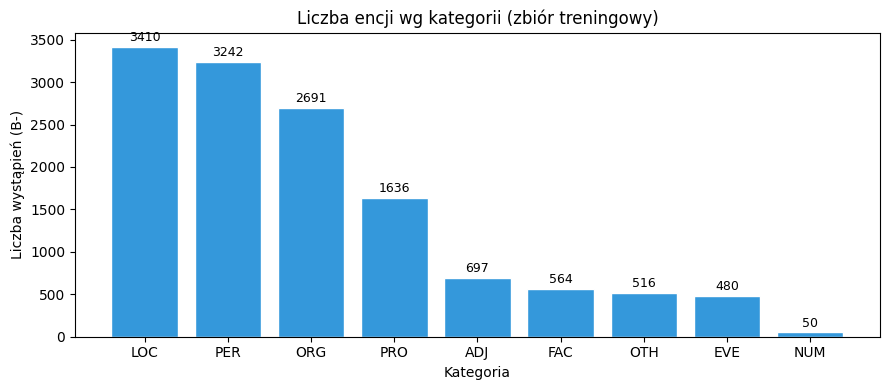


Łączna liczba encji w zbiorze treningowym: 13286


In [ ]:
# Wizualizacja — typy encji (zliczamy tylko B-, czyli pojedyncze encje)
entity_type_counts = Counter()
for ex in remapped['train']:
    for lid in ex['labels']:
        lab = ID_TO_LABEL[lid]
        if lab.startswith('B-'):
            entity_type_counts[lab[2:]] += 1

cats = list(entity_type_counts.keys())
counts = [entity_type_counts[c] for c in cats]
order = np.argsort(counts)[::-1]
cats   = [cats[i]   for i in order]
counts = [counts[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cats, counts, color='#3498db', edgecolor='white')
for i, c in enumerate(counts):
    ax.text(i, c + max(counts)*0.01, str(c), ha='center', va='bottom', fontsize=9)
ax.set_title('Liczba encji wg kategorii (zbiór treningowy)')
ax.set_ylabel('Liczba wystąpień (B-)')
ax.set_xlabel('Kategoria')
plt.tight_layout()
plt.show()

print(f"\nŁączna liczba encji w zbiorze treningowym: {sum(counts)}")

**Wnioski:**
- `O` dominuje — typowe dla NER (większość tokenów to nie nazwy własne). To przekłada się na **zaszumione `accuracy`** (model przewidujący zawsze `O` dostałby ~80–90% accuracy) — dlatego do oceny używamy **F1 na poziomie encji**, a nie tokenów.
- `PER`, `LOC` i `ORG` są zwykle najliczniejsze; `EVE` i `ADJ` często rzadkie — modele będą miały z nimi większą trudność.
- Krótkie zdania (~20 tokenów medianie) — wszystkie zmieszczą się w `max_length=128` przy tokenizacji HerBERT-em.


# 3. Metryka ewaluacji NER — F1 na poziomie encji

W odróżnieniu od klasyfikacji **token-by-token accuracy jest myląca** w NER, bo dominacja klasy `O` zawyża wynik. Standardowa metryka to **F1 na poziomie encji**:

- Encja jest poprawnie rozpoznana, gdy **model trafi w jej granice (start–end) ORAZ w jej typ**.
- Częściowe nakładanie nie liczy się jako trafienie — to surowa, ścisła metryka.
- Liczymy precision/recall/F1 globalnie, a osobno dla każdego typu encji.

Standardowa biblioteka to **`seqeval`** — implementuje dokładnie tę metrykę z notacją BIO/IOB2.


In [ ]:
# Test seqeval
y_true = [['B-PER', 'I-PER', 'O', 'B-LOC']]
y_pred = [['B-PER', 'I-PER', 'O', 'B-LOC']]
print(f"Idealne dopasowanie: F1 = {seq_f1(y_true, y_pred):.2f}")

y_pred = [['B-PER', 'O', 'O', 'B-LOC']]   # zgubiony 'I-PER' → cała encja zła
print(f"Zła granica osoby:   F1 = {seq_f1(y_true, y_pred):.2f}")

y_pred = [['B-LOC', 'I-LOC', 'O', 'B-LOC']]   # zły typ pierwszej encji
print(f"Zły typ encji:       F1 = {seq_f1(y_true, y_pred):.2f}")

Idealne dopasowanie: F1 = 1.00
Zła granica osoby:   F1 = 0.50
Zły typ encji:       F1 = 0.50


# 4. Klasyczny baseline 1 — spaCy `pl_core_news_sm`

`pl_core_news_sm` to mały statystyczny model spaCy dla polskiego (~50 MB). Pod spodem to sieć neuronowa CNN z embeddingami, **ale to nie transformer** — nie ma uwagi (attention) i działa lokalnie. Trenowany został przez zespół spaCy na polskich korpusach.

Model używa **innego zestawu etykiet** niż KPWr (głównie: `persName`, `placeName`, `geogName`, `orgName`, `date`, `time`). Musimy je zmapować do naszych 9 kategorii.


In [ ]:
import spacy
nlp = spacy.load("pl_core_news_sm")

print(f"Komponenty pipeline'u: {nlp.pipe_names}")
print(f"Etykiety NER w spaCy:  {nlp.get_pipe('ner').labels}")

Komponenty pipeline'u: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'tagger', 'attribute_ruler', 'ner']
Etykiety NER w spaCy:  ('date', 'geogName', 'orgName', 'persName', 'placeName', 'time')


In [ ]:
# Mapowanie etykiet spaCy → nasze kategorie nadrzędne KPWr.
# Uwaga: spaCy używa tagsetu inspirowanego TEI/NKJP (6 etykiet), które tylko
# częściowo pokrywają się z 9-klasową taksonomią KPWr.
#  - persName → PER (osoby; brakuje zwierząt, bóstw, postaci fikcyjnych)
#  - placeName/geogName → LOC (ale spaCy tu też wrzuca obiekty, które w KPWr
#    są w FAC — np. nazwy ulic, parków; to powoduje systematyczny rozjazd)
#  - orgName → ORG
#  - date/time → OTH (nie ma idealnego odpowiednika; KPWr nie ma osobnej
#    kategorii dla dat — daty w KPWr są zazwyczaj poza encjami nazwanymi)
# spaCy nie zna kategorii: PRO, EVE, ADJ, FAC, NUM — wszystkie encje tych typów
# w gold standardzie liczą się jako miss (false negative).
SPACY_TO_COARSE = {
    'persName':  'PER',
    'placeName': 'LOC',
    'geogName':  'LOC',
    'orgName':   'ORG',
    'date':      'OTH',
    'time':      'OTH',
}

def spacy_predict_bio(tokens):
    """Bierze listę tokenów (string), zwraca listę etykiet BIO."""
    # Łączymy tokeny w tekst — tracimy oryginalne pozycje, ale spaCy zrobi własną
    # tokenizację. Następnie przyporządkujemy encje do oryginalnych tokenów po overlapie znaków.
    text = ' '.join(tokens)

    # Pozycje znakowe oryginalnych tokenów w sklejonym tekście
    char_spans = []
    pos = 0
    for tok in tokens:
        char_spans.append((pos, pos + len(tok)))
        pos += len(tok) + 1   # +1 za spację

    doc = nlp(text)
    bio = ['O'] * len(tokens)
    for ent in doc.ents:
        cat = SPACY_TO_COARSE.get(ent.label_)
        if cat is None:
            continue
        # Znajdujemy oryginalne tokeny, które nakładają się na encję
        overlap = []
        for i, (a, b) in enumerate(char_spans):
            if a < ent.end_char and b > ent.start_char:
                overlap.append(i)
        if not overlap:
            continue
        bio[overlap[0]] = f'B-{cat}'
        for i in overlap[1:]:
            bio[i] = f'I-{cat}'
    return bio

# Test
sample = ['Jan', 'Kowalski', 'mieszka', 'w', 'Olsztynie', 'i', 'pracuje', 'w', 'Microsoft', '.']
print("Tokeny:    ", sample)
print("Predykcja: ", spacy_predict_bio(sample))

Tokeny:     ['Jan', 'Kowalski', 'mieszka', 'w', 'Olsztynie', 'i', 'pracuje', 'w', 'Microsoft', '.']
Predykcja:  ['B-PER', 'I-PER', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'B-LOC', 'O']


## 4.1. Ewaluacja spaCy na zbiorze testowym

Ewaluujemy na **podzbiorze testowym** — pełna ewaluacja byłaby wolna ze względu na koszt spaCy + nakładanie się znaków.


In [ ]:
N_EVAL_CLASSIC = 1000
test_subset = remapped['test'].shuffle(seed=SEED).select(range(min(N_EVAL_CLASSIC, len(remapped['test']))))

y_true_spacy = []
y_pred_spacy = []

for ex in tqdm(test_subset, desc="spaCy NER"):
    y_true_spacy.append([ID_TO_LABEL[l] for l in ex['labels']])
    y_pred_spacy.append(spacy_predict_bio(ex['tokens']))

print()
print("Wyniki spaCy pl_core_news_sm:")
print(f"  Precision: {seq_precision(y_true_spacy, y_pred_spacy)*100:.2f}")
print(f"  Recall:    {seq_recall(y_true_spacy,    y_pred_spacy)*100:.2f}")
print(f"  F1:        {seq_f1(y_true_spacy,        y_pred_spacy)*100:.2f}")

spaCy NER:   0%|          | 0/1000 [00:00<?, ?it/s]


Wyniki spaCy pl_core_news_sm:
  Precision: 40.91
  Recall:    44.37
  F1:        42.57


**Uwaga o wyniku spaCy:** Spodziewamy się **niskiego F1** (kilkanaście do dwudziestu kilku procent) z trzech głównych przyczyn:

1. **Niedopasowanie schematów etykiet** — spaCy nie zna kategorii `PRO`, `EVE`, `ADJ`, `FAC`, `NUM`. Wszystkie encje tych typów liczą się jako miss (false negative w recall).
2. **Systematyczny rozjazd LOC vs FAC** — spaCy oznacza nazwy ulic, parków czy mostów jako `placeName`/`geogName` (mapowane na `LOC`), a w KPWr są to `nam_fac_*` (mapowane na `FAC`). Każda taka encja to **dwa błędy naraz**: false positive w `LOC` i false negative w `FAC`.
3. **Inny korpus treningowy** — spaCy trenowany był na NKJP/innych źródłach, nie na KPWr; konwencje anotacji się różnią (gdzie zaczyna i kończy się encja, czy uwzględniać tytuły grzecznościowe itp.).

To pokazuje **fundamentalną trudność NER**: wynik silnie zależy od konwencji anotacji w danym korpusie. Modele trenowane „pod nasz dataset" zawsze wygrają z gotowcami z innego źródła.


# 5. Klasyczny baseline 2 — CRF z ręcznymi cechami

**Conditional Random Fields** (Lafferty, McCallum, Pereira, 2001) to **klasyczna**, „pre-deep-learning" metoda do oznaczania sekwencji. Przed erą BiLSTM-ów i transformerów to **CRF był standardem** w NER (m.in. Stanford NER Tagger).

Idea: dla każdego tokenu wyciągamy **ręcznie zaprojektowane cechy** (np. wielkość liter, sufiksy, kontekst sąsiednich tokenów) i uczymy model przewidujący etykiety **z uwzględnieniem zależności między sąsiednimi etykietami w sekwencji** (np. po `B-PER` częściej idzie `I-PER` niż `B-LOC`).

Implementacja: **`sklearn-crfsuite`** — wrapper na `python-crfsuite`. Nie używa GPU, działa w pełni na CPU.


In [ ]:
# Funkcja wyciągająca cechy dla tokenu na pozycji i w sekwencji `tokens`
def word_features(tokens, i):
    word = tokens[i]
    features = {
        'bias': 1.0,
        'word.lower': word.lower(),
        'word[-3:]': word[-3:],         # sufiks 3-znakowy
        'word[-2:]': word[-2:],         # sufiks 2-znakowy
        'word.isupper': word.isupper(),
        'word.istitle': word.istitle(),  # pierwsza wielka litera (np. 'Jan')
        'word.isdigit': word.isdigit(),
        'word.hasdigit': any(c.isdigit() for c in word),
        'word.length': len(word),
    }
    # Cechy z poprzedniego tokenu
    if i > 0:
        prev = tokens[i-1]
        features.update({
            '-1:word.lower':  prev.lower(),
            '-1:word.istitle': prev.istitle(),
            '-1:word.isupper': prev.isupper(),
        })
    else:
        features['BOS'] = True   # początek sekwencji

    # Cechy z następnego tokenu
    if i < len(tokens) - 1:
        nxt = tokens[i+1]
        features.update({
            '+1:word.lower':  nxt.lower(),
            '+1:word.istitle': nxt.istitle(),
            '+1:word.isupper': nxt.isupper(),
        })
    else:
        features['EOS'] = True   # koniec sekwencji

    return features

def sentence_features(tokens):
    return [word_features(tokens, i) for i in range(len(tokens))]

# Test
test_tokens = ['Jan', 'Kowalski', 'mieszka', 'w', 'Olsztynie']
feats = sentence_features(test_tokens)
print("Cechy dla tokenu 'Kowalski' (pozycja 1):")
for k, v in feats[1].items():
    print(f"  {k:<22} = {v}")

Cechy dla tokenu 'Kowalski' (pozycja 1):
  bias                   = 1.0
  word.lower             = kowalski
  word[-3:]              = ski
  word[-2:]              = ki
  word.isupper           = False
  word.istitle           = True
  word.isdigit           = False
  word.hasdigit          = False
  word.length            = 8
  -1:word.lower          = jan
  -1:word.istitle        = True
  -1:word.isupper        = False
  +1:word.lower          = mieszka
  +1:word.istitle        = False
  +1:word.isupper        = False


## 5.1. Trenowanie CRF

Trenujemy na **podzbiorze** — pełny zbiór byłby kilkukrotnie wolniejszy, a różnica jakości niewielka jak na cele dydaktyczne.


In [ ]:
# Przygotowanie zbiorów X (cechy) i y (etykiety)
TRAIN_SIZE_CRF = 5000
EVAL_SIZE_CRF  = 1000

train_subset_crf = remapped['train'].shuffle(seed=SEED).select(range(min(TRAIN_SIZE_CRF, len(remapped['train']))))
test_subset_crf  = remapped['test'].shuffle(seed=SEED).select(range(min(EVAL_SIZE_CRF, len(remapped['test']))))

X_train = [sentence_features(ex['tokens']) for ex in train_subset_crf]
y_train = [[ID_TO_LABEL[l] for l in ex['labels']] for ex in train_subset_crf]

X_test = [sentence_features(ex['tokens']) for ex in test_subset_crf]
y_test = [[ID_TO_LABEL[l] for l in ex['labels']] for ex in test_subset_crf]

print(f"Zbiór treningowy CRF: {len(X_train)} zdań")
print(f"Zbiór testowy CRF:    {len(X_test)} zdań")

Zbiór treningowy CRF: 5000 zdań
Zbiór testowy CRF:    1000 zdań


In [ ]:
# Trening CRF
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,             # regularyzacja L1 (cechy rzadkie)
    c2=0.1,             # regularyzacja L2
    max_iterations=100,
    all_possible_transitions=True,
)

import time
t0 = time.time()
crf.fit(X_train, y_train)
print(f"Czas treningu CRF: {time.time() - t0:.1f} s")

Czas treningu CRF: 17.8 s


## 5.2. Ewaluacja CRF

In [ ]:
y_pred_crf = crf.predict(X_test)

print("Wyniki CRF:")
print(f"  Precision: {seq_precision(y_test, y_pred_crf)*100:.2f}")
print(f"  Recall:    {seq_recall(y_test,    y_pred_crf)*100:.2f}")
print(f"  F1:        {seq_f1(y_test,        y_pred_crf)*100:.2f}")
print()
print("Szczegółowy raport (per kategoria):")
print(seq_classification_report(y_test, y_pred_crf, digits=3))

Wyniki CRF:
  Precision: 59.75
  Recall:    46.99
  F1:        52.61

Szczegółowy raport (per kategoria):
              precision    recall  f1-score   support

         ADJ      0.800     0.162     0.270        74
         EVE      0.273     0.067     0.107        45
         FAC      0.667     0.186     0.291        43
         LOC      0.658     0.670     0.664       279
         NUM      0.000     0.000     0.000         2
         ORG      0.557     0.471     0.511       206
         OTH      0.760     0.388     0.514        49
         PER      0.570     0.619     0.594       210
         PRO      0.459     0.230     0.306       122

   micro avg      0.598     0.470     0.526      1030
   macro avg      0.527     0.310     0.362      1030
weighted avg      0.594     0.470     0.500      1030



**Wniosek o CRF:** Wynik istotnie lepszy niż gotowy spaCy, mimo prostych cech. Główny zysk pochodzi z tego, że **CRF jest trenowany na tych samych anotacjach KPWr**, co testujemy — schemat etykiet się zgadza. Słabość CRF to **brak rozumienia semantycznego** — działa na powierzchniowych wzorcach (czy słowo zaczyna się wielką literą, jaki ma sufiks). Nie odróżni „Mickiewicza" jako osoby (poety) od „Mickiewicza" jako ulicy bez dodatkowych cech.


# 6. Pipeline API — gotowy model transformerowy

Zanim sami fine-tunujemy HerBERT-a, zobaczmy co potrafi **gotowy** model NER z HF Hub. Użyjemy `clarin-pl/FastPDN` — modelu wytrenowanego przez CLARIN-PL **dokładnie na pełnym zbiorze KPWr-NER (82 klasy)**. Tu posłuży nam jako sanity check i punkt odniesienia "ile można wyciągnąć z transformera trenowanego na pełnym datasecie".


In [ ]:
ner_pipeline_pretrained = pipeline(
    "ner",
    model="clarin-pl/FastPDN",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1,
)

# Test na przykładowym zdaniu
test_text = "Adam Mickiewicz urodził się w Zaosiu i studiował na Uniwersytecie Wileńskim."
results = ner_pipeline_pretrained(test_text)

print(f"Tekst: {test_text}\n")
print("Wykryte encje:")
for r in results:
    print(f"  '{r['word']}'  →  {r['entity_group']}  (score={r['score']:.3f})")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: clarin-pl/FastPDN
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/144 [00:00<?, ?B/s]

Tekst: Adam Mickiewicz urodził się w Zaosiu i studiował na Uniwersytecie Wileńskim.

Wykryte encje:
  'Adam Mickiewicz'  →  nam_liv_person  (score=1.000)
  'Za'  →  nam_loc_gpe_city  (score=0.999)
  'osiu'  →  nam_loc_gpe_city  (score=0.939)
  'Uniwersytecie Wileńskim'  →  nam_org_organization  (score=0.998)


**Uwaga o porównywalności:** `FastPDN` zwraca etykiety z oryginalnej listy 82 klas (`nam_liv_person`, `nam_loc_gpe_city` itp.). Nie ewaluujemy go bezpośrednio na naszej 9-klasowej wersji, bo musielibyśmy mapować jego predykcje "w drugą stronę" — to inżynierski detal. Ważne: ten model pokazuje **górną granicę** możliwości na tym datasecie (autorzy publikują F1 ~76 na pełnym KPWr-NER w wersji 82-klasowej).


# 7. Fine-tuning HerBERT — przygotowanie danych

Teraz najważniejsze — sami fine-tunujemy HerBERT-a na naszym 9-klasowym datasecie. Główna trudność token classification (vs klasyfikacja zdań z lab. 8) to **rozjazd między tokenizacją a etykietowaniem**:

- KPWr tokenizuje tekst po wyrazach (~1 token = 1 słowo).
- HerBERT używa **subword tokenizacji** (BPE) — jedno słowo może zostać podzielone na kilka subtokenów (np. `Olsztynie` → `Olsz` + `##tynie`).
- Każdy subtoken musi dostać etykietę. Konwencja: **pierwszemu subtokenowi przypisujemy etykietę słowa, kolejnym `-100`** (specjalna wartość ignorowana przez CrossEntropyLoss).

Funkcja `tokenize_and_align_labels` poniżej robi dokładnie to.


In [ ]:
MODEL_NAME = "allegro/herbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {type(tokenizer).__name__}")
print(f"Rozmiar słownika: {tokenizer.vocab_size}")

# Demo: jak HerBERT tokenizuje słowa z polskimi diakrytykami
sample_words = ['Olsztynie', 'Mickiewicz', 'Politechnika', 'biało-czerwony']
for w in sample_words:
    pieces = tokenizer.tokenize(w)
    print(f"  '{w}' → {pieces}")

config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

Tokenizer: HerbertTokenizer
Rozmiar słownika: 50000
  'Olsztynie' → ['Olsztynie</w>']
  'Mickiewicz' → ['Mickiewicz</w>']
  'Politechnika' → ['Politechnika</w>']
  'biało-czerwony' → ['biało</w>', '-</w>', 'czerwony</w>']


In [ ]:
MAX_LENGTH = 192   # Większość zdań w KPWr jest krótka (~20 tokenów słownych); 192 z zapasem na BPE.

def tokenize_and_align_labels(examples):
    """Tokenizuje tekst już-rozdzielony-na-słowa i wyrównuje etykiety do subtokenów."""
    tokenized = tokenizer(
        examples['tokens'],
        is_split_into_words=True,    # ważne — wejście to lista słów, nie surowy tekst
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    new_labels = []
    for batch_idx, labels in enumerate(examples['labels']):
        word_ids = tokenized.word_ids(batch_index=batch_idx)
        prev_word_idx = None
        aligned = []
        for word_idx in word_ids:
            if word_idx is None:
                # Specjalne tokeny (CLS, SEP, PAD) — ignoruj w loss
                aligned.append(-100)
            elif word_idx != prev_word_idx:
                # Pierwszy subtoken słowa — przypisz oryginalną etykietę
                aligned.append(labels[word_idx])
            else:
                # Kolejny subtoken tego samego słowa — ignoruj w loss
                aligned.append(-100)
            prev_word_idx = word_idx
        new_labels.append(aligned)

    tokenized['labels'] = new_labels
    return tokenized

# Test wyrównania na jednym przykładzie
demo_ex = {
    'tokens': [['Jan', 'Kowalski', 'mieszka', 'w', 'Olsztynie', '.']],
    'labels': [[LABEL_TO_ID['B-PER'], LABEL_TO_ID['I-PER'],
                LABEL_TO_ID['O'], LABEL_TO_ID['O'],
                LABEL_TO_ID['B-LOC'], LABEL_TO_ID['O']]],
}
demo_out = tokenize_and_align_labels(demo_ex)
print("Subtokeny:    ", tokenizer.convert_ids_to_tokens(demo_out['input_ids'][0]))
print("Etykiety:     ", [ID_TO_LABEL.get(l, '<-100>') if l != -100 else '<-100>'
                         for l in demo_out['labels'][0]])

Subtokeny:     ['<s>', 'Jan</w>', 'Kowalski</w>', 'mieszka</w>', 'w</w>', 'Olsztynie</w>', '.</w>', '</s>']
Etykiety:      ['<-100>', 'B-PER', 'I-PER', 'O', 'O', 'B-LOC', 'O', '<-100>']


## 7.1. Tokenizacja całych zbiorów

Dla oszczędności czasu (i mieszczenia się w darmowym Colabie T4) używamy **podzbioru** zbioru treningowego.


In [ ]:
TRAIN_SIZE_BERT = 6000
EVAL_SIZE_BERT  = 1500

small_train = remapped['train'].shuffle(seed=SEED).select(range(min(TRAIN_SIZE_BERT, len(remapped['train']))))
small_test  = remapped['test'].shuffle(seed=SEED).select(range(min(EVAL_SIZE_BERT, len(remapped['test']))))

print(f"Trening:    {len(small_train)} zdań")
print(f"Test:       {len(small_test)} zdań")

Trening:    6000 zdań
Test:       1500 zdań


In [ ]:
tokenized_train = small_train.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=small_train.column_names,
    desc="Tokenizacja zbioru treningowego",
)

tokenized_test = small_test.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=small_test.column_names,
    desc="Tokenizacja zbioru testowego",
)

print("Po tokenizacji:")
print(f"  train: {tokenized_train}")
print(f"  test:  {tokenized_test}")

Tokenizacja zbioru treningowego:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizacja zbioru testowego:   0%|          | 0/1500 [00:00<?, ? examples/s]

Po tokenizacji:
  train: Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 6000
})
  test:  Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 1500
})


# 8. Ładowanie modelu z głową token classification

`AutoModelForTokenClassification` dokłada do pre-trenowanego HerBERT-a **głowę klasyfikacyjną** — pojedynczą warstwę liniową, która z reprezentacji każdego tokenu (768-wymiarowy wektor) wylicza logity dla każdej z 19 etykiet. Ta głowa jest inicjalizowana losowo i fine-tuning ją wytrenuje od zera.


In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(COARSE_LABELS),
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Liczba etykiet: {len(COARSE_LABELS)}")
print(f"Parametrów łącznie: {n_params:,}")

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

BertForTokenClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when l

Model: allegro/herbert-base-cased
Liczba etykiet: 19
Parametrów łącznie: 123,866,899


## 8.1. Funkcja metryk dla Trainera

In [ ]:
def compute_metrics(eval_pred):
    """Trainer przekazuje logity i etykiety; konwertujemy na nazwy klas i liczymy seqeval."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Pomijamy pozycje z label = -100 (specjalne tokeny i nie-pierwsze subtokeny)
    true_labels = [
        [ID_TO_LABEL[l] for l in label if l != -100]
        for label in labels
    ]
    true_preds = [
        [ID_TO_LABEL[p] for p, l in zip(pred, label) if l != -100]
        for pred, label in zip(predictions, labels)
    ]

    return {
        'precision': seq_precision(true_labels, true_preds),
        'recall':    seq_recall(true_labels,    true_preds),
        'f1':        seq_f1(true_labels,        true_preds),
    }

## 8.2. Konfiguracja treningu

| Parametr | Wartość | Uzasadnienie |
|---|---|---|
| `learning_rate` | `3e-5` | Standard dla fine-tuningu BERT-like na sekwencyjnym oznaczaniu |
| `num_train_epochs` | `3` | Token classification zwykle wymaga więcej epok niż klasyfikacja zdań |
| `per_device_train_batch_size` | `16` | Zmieści się w VRAM T4 dla seq 192 |
| `fp16` | `True` | Mixed precision → 2× szybszy trening na T4 |
| `weight_decay` | `0.01` | Standardowa regularyzacja |


In [ ]:
training_args = TrainingArguments(
    output_dir="./herbert-kpwr-ner",
    learning_rate=3e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

# Data collator — automatycznie pad-uje tokeny i etykiety (etykiety paddingu = -100)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print("Trainer skonfigurowany.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer skonfigurowany.


## 8.3. Uruchomienie treningu

Na T4 (Colab darmowy) trening powinien zająć **ok. 5–8 minut**.


In [ ]:
train_result = trainer.train()

print()
print("=" * 60)
print("TRENING ZAKOŃCZONY")
print("=" * 60)
print(f"Czas treningu: {train_result.metrics['train_runtime']:.1f} s "
      f"({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"Finalna strata treningowa: {train_result.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.115652,0.111457,0.744760,0.754057,0.749380
2,0.073012,0.097149,0.770943,0.821473,0.795406
3,0.040657,0.104725,0.782787,0.834582,0.807855



TRENING ZAKOŃCZONY
Czas treningu: 109.1 s (1.8 min)
Finalna strata treningowa: 0.1736


## 8.4. Wizualizacja postępu treningu

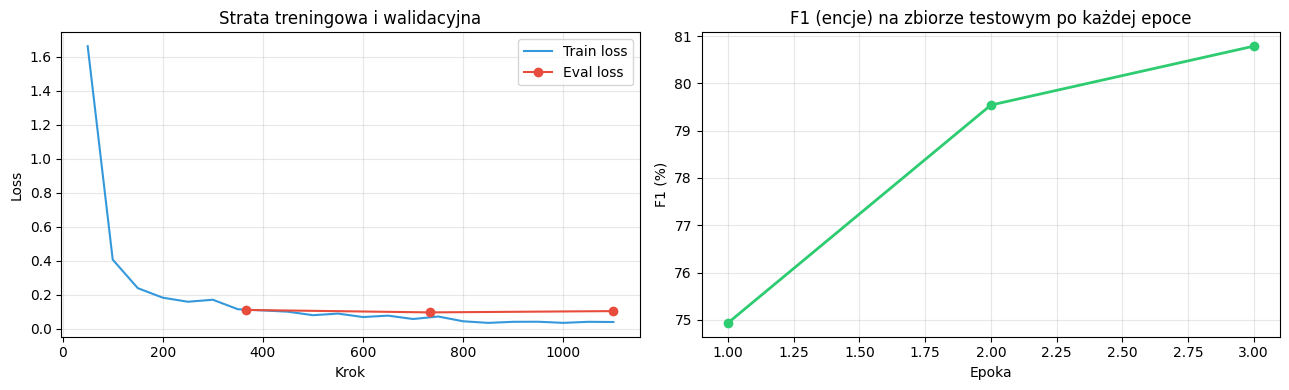

In [ ]:
logs = trainer.state.log_history

train_losses = [(l['step'], l['loss']) for l in logs if 'loss' in l and 'eval_loss' not in l]
eval_f1     = [(l['epoch'], l['eval_f1']) for l in logs if 'eval_f1' in l]
eval_loss   = [(l['epoch'], l['eval_loss']) for l in logs if 'eval_loss' in l]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, color='#3498db', linewidth=1.5, label='Train loss')
if eval_loss:
    eps, evl = zip(*eval_loss)
    # Mapujemy epokę na krok (przybliżone)
    steps_per_epoch = max(s for s, _ in train_losses) / max(eps) if train_losses else 1
    axes[0].plot([e * steps_per_epoch for e in eps], evl, 'o-', color='#e74c3c', label='Eval loss')
axes[0].set_xlabel('Krok')
axes[0].set_ylabel('Loss')
axes[0].set_title('Strata treningowa i walidacyjna')
axes[0].legend()
axes[0].grid(alpha=0.3)

if eval_f1:
    eps, f1s = zip(*eval_f1)
    axes[1].plot(eps, [100*f for f in f1s], 'o-', color='#2ecc71', linewidth=2)
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('F1 (%)')
    axes[1].set_title('F1 (encje) na zbiorze testowym po każdej epoce')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Ewaluacja końcowa — szczegółowy raport

Trainer już wyświetlił globalne metryki w trakcie treningu. Teraz zrobimy **szczegółowy raport per kategoria** dla finalnego modelu — zobaczymy, które typy encji model rozpoznaje najlepiej, a z którymi ma problem.


In [ ]:
# Predykcje na zbiorze testowym
predictions, labels, _ = trainer.predict(tokenized_test)
preds = np.argmax(predictions, axis=-1)

# Filtrujemy pozycje z labelem -100
y_true_bert = [
    [ID_TO_LABEL[l] for l in label if l != -100]
    for label in labels
]
y_pred_bert = [
    [ID_TO_LABEL[p] for p, l in zip(pred, label) if l != -100]
    for pred, label in zip(preds, labels)
]

bert_precision = seq_precision(y_true_bert, y_pred_bert) * 100
bert_recall    = seq_recall(y_true_bert,    y_pred_bert) * 100
bert_f1        = seq_f1(y_true_bert,        y_pred_bert) * 100

print(f"Wyniki HerBERT fine-tuned:")
print(f"  Precision: {bert_precision:.2f}")
print(f"  Recall:    {bert_recall:.2f}")
print(f"  F1:        {bert_f1:.2f}")
print()
print("Szczegółowy raport (per kategoria):")
print(seq_classification_report(y_true_bert, y_pred_bert, digits=3))

Wyniki HerBERT fine-tuned:
  Precision: 78.28
  Recall:    83.46
  F1:        80.79

Szczegółowy raport (per kategoria):
              precision    recall  f1-score   support

         ADJ      0.667     0.811     0.732       111
         EVE      0.494     0.609     0.545        69
         FAC      0.658     0.675     0.667        77
         LOC      0.881     0.914     0.897       421
         NUM      0.000     0.000     0.000         3
         ORG      0.796     0.826     0.810       344
         OTH      0.621     0.571     0.595        63
         PER      0.915     0.947     0.931       341
         PRO      0.613     0.723     0.663       173

   micro avg      0.783     0.835     0.808      1602
   macro avg      0.627     0.675     0.649      1602
weighted avg      0.787     0.835     0.809      1602



# 10. Porównanie wszystkich modeli

Zestawmy wyniki trzech podejść. **Uwaga o porównywalności:**
- `spaCy` był ewaluowany na podzbiorze 1000 zdań i jest "out of the box" — nie był trenowany na KPWr.
- `CRF` był trenowany na 5000 zdań KPWr i ewaluowany na podzbiorze 1000.
- `HerBERT` był fine-tunowany na 6000 zdań KPWr i ewaluowany na 1500.

Ze względu na różne podzbiory testowe wyniki nie są w pełni porównywalne, ale dają dobre **wyobrażenie o rzędzie wielkości** różnic.


In [ ]:
# Tabela podsumowująca
spacy_p = seq_precision(y_true_spacy, y_pred_spacy) * 100
spacy_r = seq_recall(y_true_spacy,    y_pred_spacy) * 100
spacy_f1 = seq_f1(y_true_spacy,        y_pred_spacy) * 100

crf_p = seq_precision(y_test, y_pred_crf) * 100
crf_r = seq_recall(y_test,    y_pred_crf) * 100
crf_f1 = seq_f1(y_test,        y_pred_crf) * 100

comparison = pd.DataFrame({
    'Model':       ['spaCy pl_core_news_sm', 'CRF + ręczne cechy', 'HerBERT fine-tuned'],
    'Precision':   [round(spacy_p, 2), round(crf_p, 2), round(bert_precision, 2)],
    'Recall':      [round(spacy_r, 2), round(crf_r, 2), round(bert_recall,    2)],
    'F1':          [round(spacy_f1, 2), round(crf_f1, 2), round(bert_f1,       2)],
    'Trening':     ['—',                 f'{TRAIN_SIZE_CRF} zdań', f'{TRAIN_SIZE_BERT} zdań'],
})
print(comparison.to_string(index=False))

                Model  Precision  Recall    F1   Trening
spaCy pl_core_news_sm      40.91   44.37 42.57         —
   CRF + ręczne cechy      59.75   46.99 52.61 5000 zdań
   HerBERT fine-tuned      78.28   83.46 80.79 6000 zdań


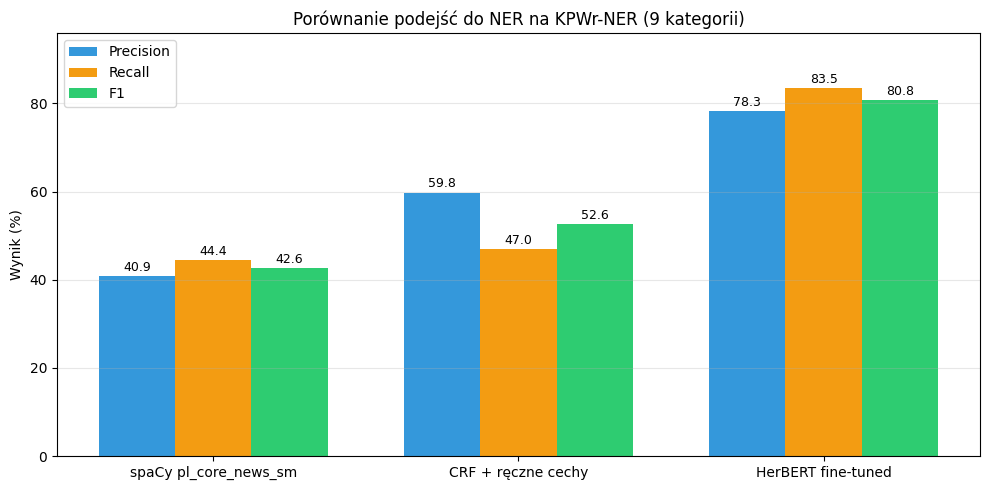

In [ ]:
# Wykres porównawczy
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.25

ax.bar(x - width, comparison['Precision'], width, label='Precision', color='#3498db')
ax.bar(x,         comparison['Recall'],    width, label='Recall',    color='#f39c12')
ax.bar(x + width, comparison['F1'],        width, label='F1',         color='#2ecc71')

# Etykiety wartości na słupkach
for i, row in comparison.iterrows():
    for j, (col, off) in enumerate([('Precision', -width), ('Recall', 0), ('F1', width)]):
        ax.text(i + off, row[col] + 0.5, f'{row[col]:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Wynik (%)')
ax.set_title('Porównanie podejść do NER na KPWr-NER (9 kategorii)')
ax.legend()
ax.set_ylim(0, max(comparison['F1'].max(), comparison['Precision'].max(), comparison['Recall'].max()) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10.1. Interpretacja różnic

Oczekiwane obserwacje:

- **HerBERT bije CRF o duży margines** — kontekstowe embeddingi (768 wymiarów na token, świadome **całego zdania** dzięki uwadze) pokonują ręcznie zaprojektowane cechy CRF, mimo podobnego rozmiaru zbioru treningowego.
- **CRF deklasuje spaCy out-of-the-box** — bo CRF widział te same anotacje co test. Pokazuje to, że **dopasowanie schematu etykiet do zadania jest często ważniejsze niż „mocniejszy" model**.
- **Recall transformera jest zwykle wyższy niż precision** — w token classification model jest „chętny do oznaczania", co przekłada się na nadprodukcję encji.
- **Klasy mniejszościowe (`EVE`, `ADJ`, `OTH`) wciąż są trudne** dla wszystkich modeli — to typowe wyzwanie NER. Bez augmentacji danych albo ważenia loss-u trudno je nauczyć.

**Generalna lekcja:** transformer to dziś standard dla NER, ale CRF nadal ma swoje miejsce — kiedy nie mamy GPU, kiedy domena jest bardzo wąska (medyczne raporty, dokumenty prawne) i mamy świetnie zaprojektowane cechy domenowe, oraz kiedy potrzebujemy wytłumaczalności (każda cecha ma wagę).


# 11. Predykcja na nowych tekstach — pipeline HF

Do wygodnego użytkowania wytrenowanego modelu używamy klasy `pipeline("ner")` z biblioteki transformers. Z `aggregation_strategy="simple"` otrzymujemy gotowe encje (sklejone subtokeny).


In [ ]:
ner_pipeline = pipeline(
    "ner",
    model=trainer.model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1,
)

# Własny tekst 1 — Olsztyn i UWM
text_1 = (
    "Uniwersytet Warmińsko-Mazurski w Olsztynie powstał w 1999 roku z połączenia "
    "Akademii Rolniczo-Technicznej, Wyższej Szkoły Pedagogicznej oraz "
    "Warmińskiego Instytutu Teologicznego. Pierwszym rektorem został profesor "
    "Ryszard Górecki. Główny kampus znajduje się w olsztyńskim Kortowie, "
    "nad jeziorem Kortowskim."
)

print(f"Tekst:\n{text_1}\n")
print("Wykryte encje:")
for ent in ner_pipeline(text_1):
    print(f"  '{ent['word']:<40}' → {ent['entity_group']}  (score={ent['score']:.3f})")

Tekst:
Uniwersytet Warmińsko-Mazurski w Olsztynie powstał w 1999 roku z połączenia Akademii Rolniczo-Technicznej, Wyższej Szkoły Pedagogicznej oraz Warmińskiego Instytutu Teologicznego. Pierwszym rektorem został profesor Ryszard Górecki. Główny kampus znajduje się w olsztyńskim Kortowie, nad jeziorem Kortowskim.

Wykryte encje:
  'Uniwersytet Warmińsko - Mazurski w Olsztynie' → ORG  (score=0.922)
  'Akademii Rolniczo - Technicznej         ' → ORG  (score=0.994)
  'Wyższej Szkoły Pedagogicznej            ' → ORG  (score=0.992)
  'War                                     ' → ORG  (score=0.984)
  'mińskiego Instytutu Teologicznego       ' → ORG  (score=0.974)
  'Ryszard Górecki                         ' → PER  (score=0.995)
  'olszty                                  ' → ADJ  (score=0.867)
  'ńskim                                   ' → ADJ  (score=0.737)
  'Kor                                     ' → LOC  (score=0.992)
  'towie                                   ' → LOC  (score=0.709)
  'Kor

In [ ]:
# Własny tekst 2 — historia
text_2 = (
    "Mikołaj Kopernik urodził się w 1473 roku w Toruniu. Studiował na Akademii "
    "Krakowskiej, a następnie we włoskich uniwersytetach w Bolonii i Padwie. "
    "Większość życia spędził we Fromborku, gdzie napisał dzieło "
    "O obrotach sfer niebieskich."
)

print(f"Tekst:\n{text_2}\n")
print("Wykryte encje:")
for ent in ner_pipeline(text_2):
    print(f"  '{ent['word']:<40}' → {ent['entity_group']}  (score={ent['score']:.3f})")

Tekst:
Mikołaj Kopernik urodził się w 1473 roku w Toruniu. Studiował na Akademii Krakowskiej, a następnie we włoskich uniwersytetach w Bolonii i Padwie. Większość życia spędził we Fromborku, gdzie napisał dzieło O obrotach sfer niebieskich.

Wykryte encje:
  'Mikołaj Kopernik                        ' → PER  (score=0.993)
  'Toruniu                                 ' → LOC  (score=0.995)
  'Akademii Krakowskiej                    ' → ORG  (score=0.989)
  'włoskich                                ' → ADJ  (score=0.880)
  'Bo                                      ' → LOC  (score=0.995)
  'lonii                                   ' → LOC  (score=0.977)
  'Pad                                     ' → LOC  (score=0.995)
  'wie                                     ' → LOC  (score=0.982)
  'F                                       ' → LOC  (score=0.992)
  'rom                                     ' → LOC  (score=0.973)
  'bor                                     ' → LOC  (score=0.876)
  'ku            

In [ ]:
# Własny tekst 3 — krótkie zdania, mix kategorii
texts_3 = [
    "Apple wypuścił nowego iPhone'a 15 we wrześniu 2023.",
    "Robert Lewandowski strzelił gola dla FC Barcelona.",
    "Pociąg z Warszawy do Olsztyna jechał 3 godziny.",
    "Festiwal Open'er odbywa się co roku w Gdyni.",
]

for t in texts_3:
    ents = ner_pipeline(t)
    print(f"Tekst: {t}")
    if ents:
        for e in ents:
            print(f"  '{e['word']}' → {e['entity_group']} ({e['score']:.2f})")
    else:
        print("  (brak encji)")
    print()

Tekst: Apple wypuścił nowego iPhone'a 15 we wrześniu 2023.
  'Apple' → ORG (0.96)
  'i' → PRO (0.96)
  'Phone ' a 15' → PRO (0.73)

Tekst: Robert Lewandowski strzelił gola dla FC Barcelona.
  'Robert Lewandowski' → PER (0.99)
  'FC Barcelona' → ORG (0.99)

Tekst: Pociąg z Warszawy do Olsztyna jechał 3 godziny.
  'Warszawy' → LOC (1.00)
  'Olsztyna' → LOC (1.00)

Tekst: Festiwal Open'er odbywa się co roku w Gdyni.
  'Festiwal Open ' er' → EVE (0.90)
  'Gdyni' → LOC (1.00)



# 12. Analiza błędów

Przyjrzyjmy się przykładom, na których HerBERT się myli — to pomaga zrozumieć granice modelu.


In [ ]:
# Zbieramy przykłady, dla których predykcje różnią się od złotych etykiet
errors = []
for i, (true_seq, pred_seq) in enumerate(zip(y_true_bert, y_pred_bert)):
    if true_seq != pred_seq:
        # Odzyskujemy oryginalne tokeny (z small_test, w tym samym porządku)
        tokens = small_test[i]['tokens']
        # Zabezpieczenie: tokeny mogły zostać przycięte przy tokenizacji
        n = min(len(tokens), len(true_seq), len(pred_seq))
        diffs = sum(t != p for t, p in zip(true_seq[:n], pred_seq[:n]))
        errors.append({
            'idx': i,
            'tokens': tokens[:n],
            'gold':   true_seq[:n],
            'pred':   pred_seq[:n],
            'diffs':  diffs,
        })

print(f"Zdania z co najmniej jednym błędem: {len(errors)} / {len(y_true_bert)} ({100*len(errors)/len(y_true_bert):.1f}%)")

Zdania z co najmniej jednym błędem: 264 / 1500 (17.6%)


In [ ]:
# Pokażemy 3 przykłady z największą liczbą różnic
errors_sorted = sorted(errors, key=lambda x: -x['diffs'])[:3]

for ex in errors_sorted:
    print(f"--- Zdanie #{ex['idx']} (różnic: {ex['diffs']}) ---")
    print(f"{'TOKEN':<25} {'GOLD':<10} {'PRED':<10}")
    for tok, g, p in zip(ex['tokens'], ex['gold'], ex['pred']):
        marker = "  ←" if g != p else ""
        print(f"{tok:<25} {g:<10} {p:<10}{marker}")
    print()

--- Zdanie #124 (różnic: 36) ---
TOKEN                     GOLD       PRED      
W                         O          O         
dniu                      O          O         
5                         O          O         
listopada                 O          O         
2009                      O          O         
r                         O          O         
.                         O          O         
rozpoczęły                O          O         
się                       O          O         
konsultacje               O          O         
społeczne                 O          O         
projektu                  O          O         
„                         O          O         
Programu                  B-EVE      B-PRO       ←
ochrony                   I-EVE      I-PRO       ←
powietrza                 I-EVE      I-PRO       ←
dla                       I-EVE      I-PRO       ←
czterech                  I-EVE      O           ←
stref                     I-EVE      I-P

# 13. Zapis modelu

Zachowujemy wytrenowany model lokalnie. Można go potem załadować przez `from_pretrained(sciezka)` lub opublikować na Hugging Face Hub.


In [ ]:
MODEL_DIR = "./herbert-kpwr-ner-finetuned"
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

import os
total_size_mb = sum(
    os.path.getsize(os.path.join(MODEL_DIR, f))
    for f in os.listdir(MODEL_DIR)
    if os.path.isfile(os.path.join(MODEL_DIR, f))
) / 1e6
print(f"Model zapisany w: {MODEL_DIR}")
print(f"Łączny rozmiar: {total_size_mb:.1f} MB")
print("Zawartość:")
for f in sorted(os.listdir(MODEL_DIR)):
    size_mb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1e6
    print(f"  {f:<35} {size_mb:>8.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model zapisany w: ./herbert-kpwr-ner-finetuned
Łączny rozmiar: 499.2 MB
Zawartość:
  config.json                              0.0 MB
  model.safetensors                      495.5 MB
  tokenizer.json                           3.7 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB


In [ ]:
# Test ładowania zapisanego modelu (tak jakbyśmy uruchomili notatnik od nowa)
from transformers import pipeline as hf_pipeline

loaded_ner = hf_pipeline(
    "ner",
    model=MODEL_DIR,
    tokenizer=MODEL_DIR,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1,
)

test_text = (
    "Jezioro Śniardwy o powierzchni 113 km² jest największym jeziorem w Polsce. "
    "Znajduje się w województwie warmińsko-mazurskim, niedaleko Mikołajek."
)

print(f"Tekst: {test_text}\n")
print("Encje (z załadowanego modelu):")
for ent in loaded_ner(test_text):
    print(f"  '{ent['word']}' → {ent['entity_group']} ({ent['score']:.3f})")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tekst: Jezioro Śniardwy o powierzchni 113 km² jest największym jeziorem w Polsce. Znajduje się w województwie warmińsko-mazurskim, niedaleko Mikołajek.

Encje (z załadowanego modelu):
  'Śniardwy' → LOC (0.888)
  'Polsce' → LOC (0.996)
  'warmińsko - mazurskim' → LOC (0.981)
  'Mikoła' → LOC (0.995)
  'jek' → LOC (0.722)


# Ćwiczenia

## Ćwiczenie A: NER na artykule Wikipedii

Zastosuj wytrenowany model na artykule z polskiej Wikipedii i policz statystyki rozpoznanych encji.

**Kroki:**
1. Pobierz treść artykułu o **swoim ulubionym mieście** przez bibliotekę `wikipedia`.
2. Podziel tekst na zdania (np. funkcją `nltk.sent_tokenize` albo prostym `re.split(r'(?<=[.!?])\s+', text)`).
3. Dla każdego zdania uruchom `loaded_ner` i zbierz wszystkie encje.
4. Zlicz, ile jest encji każdego typu (`Counter` po `entity_group`).
5. Pokaż 10 najczęściej występujących encji (z `entity_group='LOC'` lub `'PER'`).

**Pytanie do refleksji:** czy model częściej myli się na nazwiskach, czy na nazwach miejsc? Dlaczego?


In [ ]:
# ============================================================
# Ćwiczenie A — NER na artykule Wikipedii
# ============================================================

!pip install -q wikipedia

import wikipedia
from collections import Counter
import re

wikipedia.set_lang("pl")

# 1. Pobranie artykułu (zmień tytuł na własny)
article_title = "Olsztyn"
article_text = wikipedia.page(article_title).content

print(f"Artykuł '{article_title}' — {len(article_text)} znaków, "
      f"{len(article_text.split())} słów (przybliżenie).")

# 2. Podział na zdania (prosta heurystyka)
sentences = re.split(r'(?<=[.!?])\s+', article_text)
sentences = [s.strip() for s in sentences if 10 < len(s.strip()) < 600]
print(f"Liczba zdań do analizy: {len(sentences)}")

  Preparing metadata (setup.py) ... done
Artykuł 'Olsztyn' — 77465 znaków, 10622 słów (przybliżenie).
Liczba zdań do analizy: 728


In [ ]:
# 3. Uruchomienie modelu na każdym zdaniu (ograniczamy do pierwszych N dla szybkości)
N = 200
all_entities = []
for sent in tqdm(sentences[:N], desc="NER"):
    for ent in loaded_ner(sent):
        all_entities.append({
            'word':   ent['word'].strip(),
            'type':   ent['entity_group'],
            'score':  ent['score'],
            'sent':   sent,
        })

print(f"\nZnaleziono łącznie {len(all_entities)} encji.")

# 4. Rozkład typów
type_counts = Counter(e['type'] for e in all_entities)
print("\nRozkład typów encji:")
for t, c in type_counts.most_common():
    print(f"  {t:<10} {c}")

NER:   0%|          | 0/200 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Znaleziono łącznie 791 encji.

Rozkład typów encji:
  LOC        446
  ADJ        122
  ORG        104
  PER        87
  FAC        20
  PRO        12


In [ ]:
# 5. Top encje — najczęstsze nazwiska i miejsca
import pandas as pd

df_ents = pd.DataFrame(all_entities)
print("Top 10 nazwisk (PER):")
print(df_ents[df_ents['type'] == 'PER']['word'].value_counts().head(10))
print()
print("Top 10 lokalizacji (LOC):")
print(df_ents[df_ents['type'] == 'LOC']['word'].value_counts().head(10))

Top 10 nazwisk (PER):
word
Johan          3
da             2
Kie            2
j              2
stu            2
Har            2
Jakuba         2
ta             2
Jana z Łajs    2
glade          2
Name: count, dtype: int64

Top 10 lokalizacji (LOC):
word
Olsztyna    22
Olsztyn     16
War         12
Łyną        10
Bart         8
Po           7
Al           6
Bar          6
mii          6
Kor          5
Name: count, dtype: int64


In [ ]:
# Miejsce na własny artykuł (I)
#
#

In [ ]:
# Miejsce na własny artykuł (II)
#
#

## Ćwiczenie B: Pełny zbiór i wszystkie 82 klasy

Powtórz fine-tuning **bez agregowania klas** — tj. na pełnym schemacie 82-klasowym KPWr-NER. Porównaj globalny F1 z naszą wersją 9-klasową.

**Wskazówki:**
- Pomiń całe mapowanie `fine_to_coarse` — używaj `original_label_list` bezpośrednio.
- Liczba etykiet `num_labels = len(original_label_list)` (~165 z BIO).
- Spodziewaj się **niższego F1 ogólnego** (rzadkie klasy z 5–20 wystąpieniami będą miały F1 = 0), ale szczegółowy raport pokaże, które klasy działają, a które nie.
- Rozważ większy zbiór treningowy (`TRAIN_SIZE_BERT = 15000`) i 4 epoki — będzie kosztowo ok. 15–20 min na T4.

**Pytanie:** o ile spada F1 makro? Ile klas ma F1 < 0.1 (prawie nigdy nie rozpoznane)?


In [ ]:
# Ćwiczenie B — szkielet
# 1. Tokenizacja używa już 'ner' (oryginalna kolumna), nie 'labels' z remapowaniem
# def tokenize_full(examples):
#     ...
#     # examples['ner'] zamiast examples['labels']
#
# 2. Konfiguracja modelu z większą liczbą klas
# model_full = AutoModelForTokenClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=len(original_label_list),
#     id2label={i: l for i, l in enumerate(original_label_list)},
#     label2id={l: i for i, l in enumerate(original_label_list)},
# )
#
# 3. compute_metrics — analogicznie, używając original_label_list zamiast ID_TO_LABEL


## Ćwiczenie C: zero-shot NER z modelem multilingwalnym

Sprawdź, czy duży **multilingwalny** transformer NER trenowany na innym datasecie poradzi sobie zero-shot na polskim KPWr.

**Wskazówki:**
1. Załaduj model `Davlan/xlm-roberta-base-ner-hrl` (HRL = High Resource Languages, ale uczony na języku polskim w zestawie).
2. Uruchom go przez `pipeline("ner", aggregation_strategy="simple")` na **tym samym** zbiorze testowym KPWr.
3. Mapowanie etykiet: model używa CoNLL-style — `PER`, `LOC`, `ORG`, `MISC`. Większość naszych kategorii ma odpowiedniki.
4. Policz seqeval F1 i porównaj z naszym fine-tunowanym HerBERT-em.

**Pytanie:** o ile gorszy/lepszy jest zero-shot? Czy warto by było robić własny fine-tuning, gdyby ten model dawał już 80% naszego wyniku?


In [ ]:
# Ćwiczenie C — szkielet
# from transformers import pipeline
#
# zero_shot_ner = pipeline(
#     "ner",
#     model="Davlan/xlm-roberta-base-ner-hrl",
#     aggregation_strategy="simple",
#     device=0 if torch.cuda.is_available() else -1,
# )
#
# # ... mapowanie predykcji do BIO i ewaluacja seqeval
